In [1]:
# Plot BMR for every health variable

In [2]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure, land_filter

In [3]:
# === Path config ===
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/bmr/"

In [4]:
# === Health variables ===
# COPD (chronic obstructive pulonary disease)
# LRI (lower respiratory infection)
# IHD (ischemic heart disease)
# DM2 (type 2 diabetes)
# LC (tracheal, bronchus, and lung cancer)
# Stroke
health_vars = ["COPD", "LRI", "IHD", "DM2", "LC", "Stroke"]

In [ ]:
def plot_bmr(da):
    # Create figure
    fig = plt.figure(figsize=autosize_figure(1, 1))
    gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    # Compute discrete levels
    levels = MaxNLocator(nbins=8).tick_values(bmr_mean.min(), bmr_mean.max())
    cmap = plt.get_cmap('viridis')  # or any other colormap you prefer
    norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    # First panel
    ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
    cb = da.plot(
        transform=crs,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"Baseline Mortality Rate for {health_VAR}\n 1990-2009 av.", fontsize=16)

    # First colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal',
                           boundaries=levels, ticks=levels)
    col_bar.set_label("BMR per 100,000", fontsize=13)

    plt.tight_layout()

    out_file = f"GBD_BMR_mean_{health_VAR}_1990-2009.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

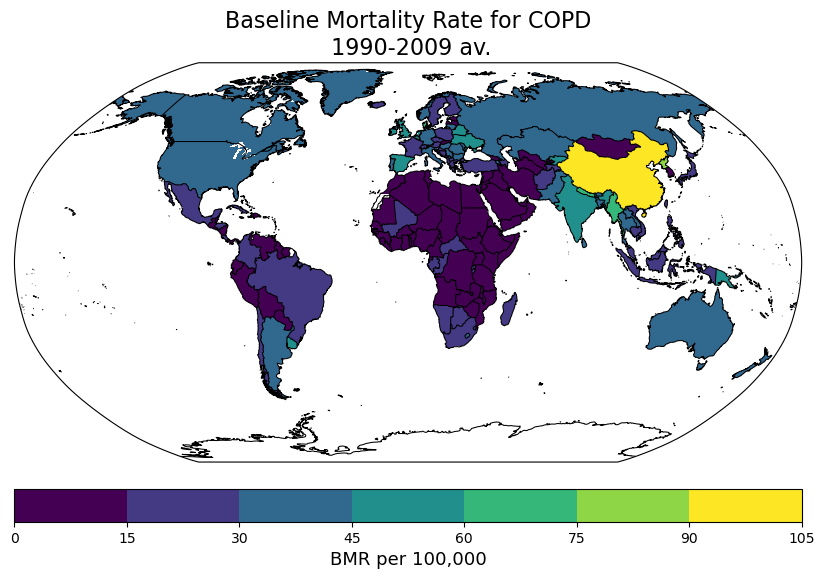

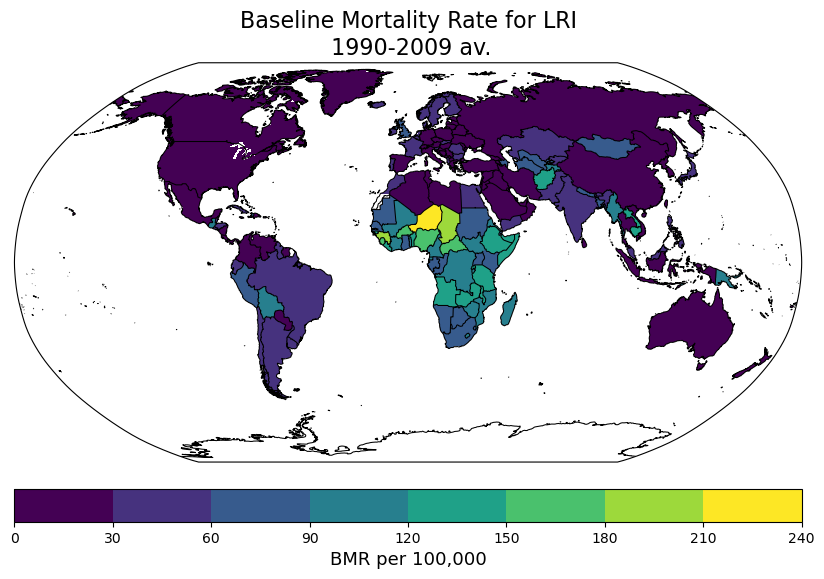

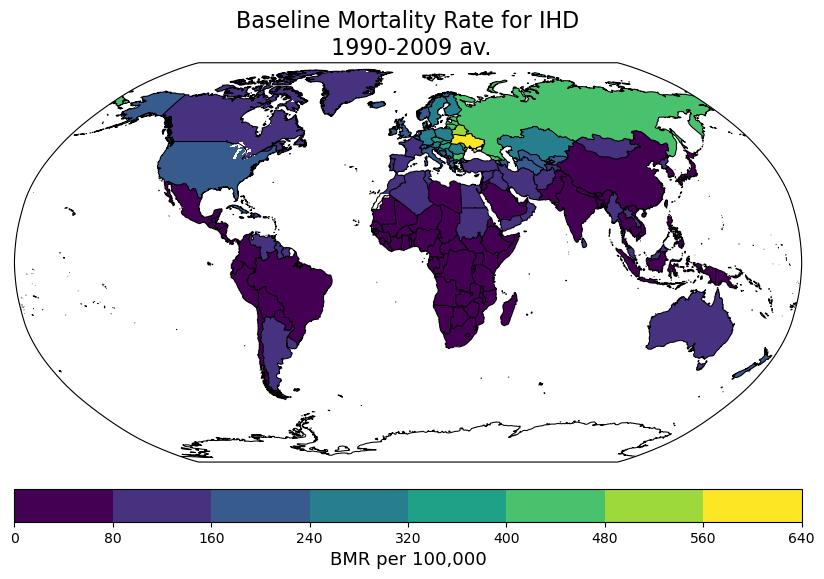

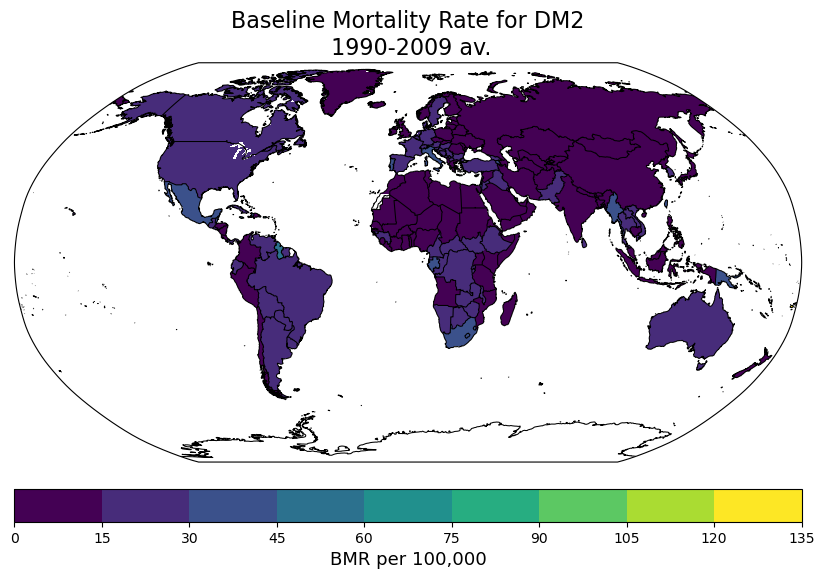

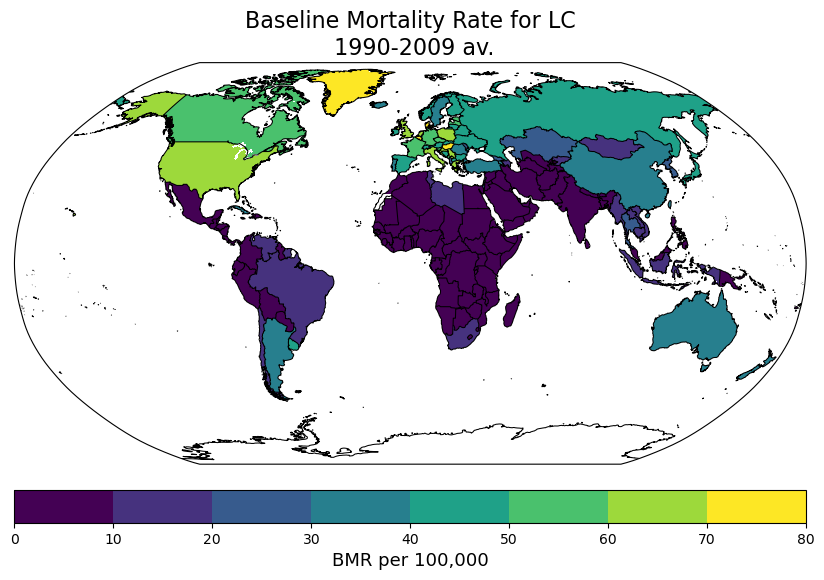

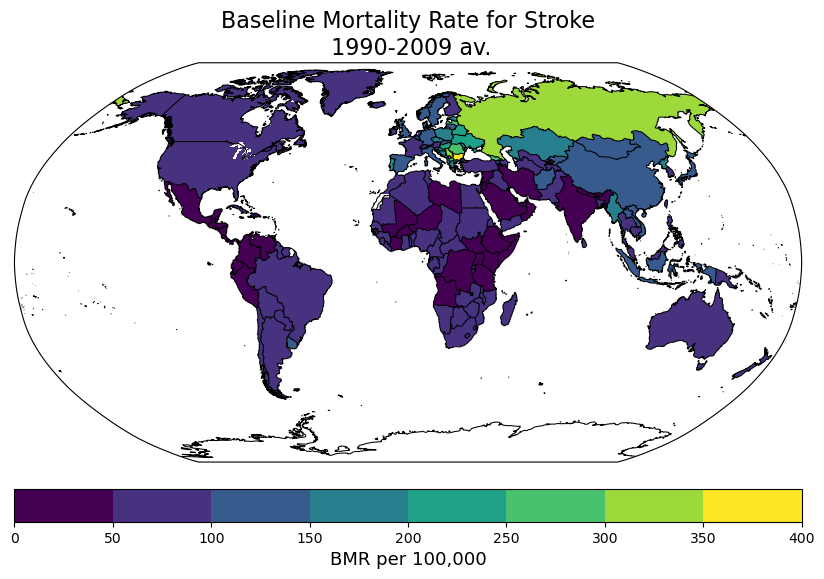

In [5]:
# === Main loop ===

for health_VAR in health_vars:
    bmr_file = f"GBD_BMR_Country_Mask_{health_VAR}_1990-2009.nc"
    bmr_path = os.path.join(BMR_DIR, bmr_file)
    bmr = xr.open_dataarray(bmr_path)

    # To be in units "per 100,000" and mask ocean
    bmr_mean = land_filter(bmr.sel(quantile="mean") * 100000)

    plot_bmr(bmr_mean)